##### Application of Levenberg-Marquardt via Chapman-Richards algorithm
* $$y(t) = \alpha(1 - \beta e^{-kt})^\frac{1}{1- m}$$
Where: 
* $y(t)$ is the size at time $t$ (i.e Tree Height)
* $\alpha$ is the upper asymptote (i.e Max size)
* $\beta$ is the scaling parameter (i.e related to initial size)
* $m$ is the shape parameter (i.e controls curve shape)
---
Intuitively it represents forest growth
* Slow Growth (i.e the trees are young)
* Rapid Growth (i.e optimal conditions)
* Plateau (i.e reaching maximum size)
---
* Goal is to find optimal parameters for $\alpha, \beta, k, m$
---
The Jacbian form of Chapman-Richards is:
\begin{equation}
J =\begin{bmatrix}\frac{\partial}{\partial \alpha} & \frac{\partial}{\partial \beta} & \frac{\partial}{\partial k} & \frac{\partial}{\partial m}
\end{bmatrix}
\end{equation}



\begin{equation}
J =\begin{bmatrix} (1 - \beta e^{-kt})^\frac{1}{1- m}, & \alpha \frac{1}{1 - m}(1 - \beta e^{-kt})^{\frac{1}{1- m}-1}(-e^{-kt}), & \alpha \frac{1}{1 - m}(1 - \beta e^{-kt})^{\frac{1}{1- m}-1}(\beta te^{-kt}), & \alpha(e^{\frac{1}{1 - m}\ln(1 - \beta e^{-kt})})\frac{\ln(1 - \beta e^{k-t})}{(1 - m)^2}
\end{bmatrix}
\end{equation}
---

##### The residuals in general is:
$r_i(\theta) = y_i - f(t_i, \theta)$
* $y_i$ is the observed data
* $f(t_i, \theta)$ is the model prediction
* $r_i$ is the error at point $i$
##### Therefore, for Chapman-Richard the residual models is:
* $r_i(\alpha, \beta, k, m) = y_i - \alpha(1 - \beta e^{-kt_i})^\frac{1}{1 - m}$
* So, the non- linear square minimizers $\lvert r(\theta) \rVert^2$ = $\sum_{i} r_i^2$

In [1]:
import numpy as np 
import matplotlib.pyplot as plt 


In [19]:
# Synthetic data

t = np.array([1,2,3,4,5,6,7,8], dtype=float)
theta = np.array([15.0, 0.0, 0.3, 0.6]) # [alpha, b_raw, k, m]
iterations = 20
lam = 1.0
history = []
y_true = (20 *(1 - 0.5* np.exp(-0.4 * t))**(1/ (1 - 0.5)))
noise = np.random.normal(0, 0.5, size=len(t))
y = y_true + noise

# ----------------------
# Residuals
# ----------------------

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# def Chapman_Richardson(alpha, b_raw, k, m, t):
#     base =  sigmoid(b_raw)
#     m = sigmoid(m)
#     k = np.exp(k) # ensure k > 0
#     base = np.clip(base, 1e-8, None) # avoid negative or zero base
#     return alpha * base**(1 / (1 - m))

def Chapman_Richardson(alpha, b_raw, k_raw, m_raw, t):
    beta = sigmoid(b_raw)
    m = sigmoid(m_raw)
    k = np.exp(k_raw)

    base = 1 - beta * np.exp(-k * t)
    base = np.clip(base, 1e-8, None)

    return alpha * base**(1 / (1 - m))

def res(theta):
    alpha, b_raw, k, m = theta
    return (y) - Chapman_Richardson(alpha, b_raw, k, m, t)

def Jacobian(theta):
    # alpha, b_raw, k, m = theta
    # beta = sigmoid(b_raw)
    # dbeta = beta * (1 - beta)
    # exp_term = beta * np.exp(-k * t)
    # base = (1 - exp_term)
    # base = np.clip(base, 1e-8, None) # avoid negative or zero base
    alpha, b_raw, k_raw, m_raw = theta

    beta = sigmoid(b_raw)
    dbeta = beta * (1 - beta)

    m = sigmoid(m_raw)
    dm = m * (1 - m)

    k = np.exp(k_raw)
    dk = k

    exp_term = np.exp(-k * t)
    base = 1 - beta * exp_term
    base = np.clip(base, 1e-8, None)
    c = 1 / (1 - m)
    J = np.zeros((len(t), 4))
    # J[:, 0] = base**c
    # J[:, 1] = alpha * c * base**(c - 1) * -np.exp(-k * t) * dbeta
    # # 1. J[:, 2] = alpha * c * base**(c - 1) * (sigmoid(b_raw) * t * np.exp(-k * t))
    # # 2. J[:, 2] = alpha * c * base**(c - 1) * (beta * t * np.exp(-k * t))
    # J[:, 2] = (alpha * c * base**(c - 1) * (beta * t * np.exp(-k * t)) * k)
    # # J[:, 3] = alpha * (np.exp((c) * np.log(base)) * (-np.log(base)/(1 - m)**2))
    # J[:, 3] = alpha * base**c * (-np.log(base) / (1 - m)**2)
    # ∂/∂alpha
    J[:, 0] = base**c

    # ∂/∂b_raw
    J[:, 1] = alpha * c * base**(c - 1) * (-exp_term) * dbeta

    # ∂/∂k_raw (chain rule!)
    J[:, 2] = alpha * c * base**(c - 1) * (beta * t * exp_term) * dk

    # ∂/∂m_raw (chain rule!)
    J[:, 3] = alpha * base**c * (-np.log(base) / (1 - m)**2) * dm
    return J

for it in range(iterations):
    r = res(theta)
    J = Jacobian(theta)

    JTJ = J.T @ J # curvature 
    JTr = J.T @ r # direction
    A = JTJ + lam * np.eye(4)
    delta = np.linalg.solve(A, -JTr)

    theta_new = theta + delta

    err = np.sum(r**2)
    err_new = np.sum(res(theta_new)**2)
    history.append(theta.copy())

    print(f"iter {it}: theta={theta}, err={err:.4f}, λ={lam:.4f}")

    if err_new < err:
        theta = theta_new
        lam *= 0.7
    else:
        lam *= 2.0

print("\nFinal parameters:", theta)


iter 0: theta=[15.   0.   0.3  0.6], err=53.1679, λ=1.0000
iter 1: theta=[15.   0.   0.3  0.6], err=53.1679, λ=2.0000
iter 2: theta=[15.   0.   0.3  0.6], err=53.1679, λ=4.0000
iter 3: theta=[15.   0.   0.3  0.6], err=53.1679, λ=8.0000
iter 4: theta=[15.   0.   0.3  0.6], err=53.1679, λ=16.0000
iter 5: theta=[15.   0.   0.3  0.6], err=53.1679, λ=32.0000
iter 6: theta=[15.   0.   0.3  0.6], err=53.1679, λ=64.0000
iter 7: theta=[15.   0.   0.3  0.6], err=53.1679, λ=128.0000
iter 8: theta=[15.   0.   0.3  0.6], err=53.1679, λ=256.0000
iter 9: theta=[15.   0.   0.3  0.6], err=53.1679, λ=512.0000
iter 10: theta=[15.   0.   0.3  0.6], err=53.1679, λ=1024.0000
iter 11: theta=[15.   0.   0.3  0.6], err=53.1679, λ=2048.0000
iter 12: theta=[15.   0.   0.3  0.6], err=53.1679, λ=4096.0000
iter 13: theta=[15.   0.   0.3  0.6], err=53.1679, λ=8192.0000
iter 14: theta=[15.   0.   0.3  0.6], err=53.1679, λ=16384.0000
iter 15: theta=[15.   0.   0.3  0.6], err=53.1679, λ=32768.0000
iter 16: theta=[15.  

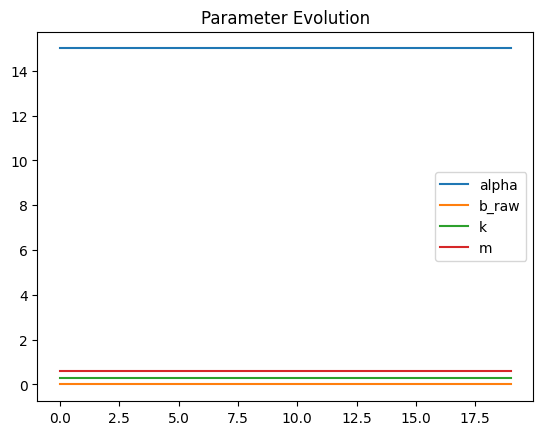

In [20]:
history = np.array(history)

plt.plot(history[:,0], label="alpha")
plt.plot(history[:,1], label="b_raw")
plt.plot(history[:,2], label="k")
plt.plot(history[:,3], label="m")
plt.legend()
plt.title("Parameter Evolution")
plt.show()

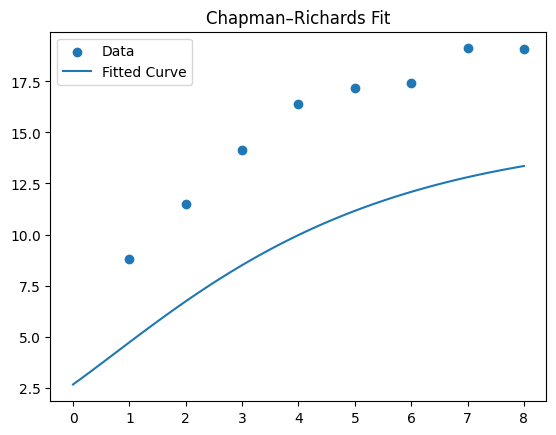

In [21]:
t_dense = np.linspace(0, 8, 100)

def model_dense(theta):
    alpha, b_raw, k, m = theta
    beta = sigmoid(b_raw)

    base = 1 - beta * np.exp(-k * t_dense)
    base = np.clip(base, 1e-8, None)

    return alpha * base**(1 / (1 - m))

plt.scatter(t, y, label="Data")
plt.plot(t_dense, model_dense(theta), label="Fitted Curve")
plt.legend()
plt.title("Chapman–Richards Fit")
plt.show()